In [1]:
import numpy as np
import pandas as pd
%matplotlib inline
import matplotlib.pyplot as plt
import matplotlib as mpl
from scipy.constants import Avogadro

hexcolors = [
    '#D1B8D7', '#AE76A3', '#882E72',
    '#1965B0', '#5289C7', '#7BAFDE',
    '#4EB265', '#90C987', '#CAE0AB',
    '#F7F056', '#F6C141', '#F1932D',
    '#E8601C', '#DC050C', '#777777'
]
 
colornames = [
    'purple1','purple2','purple3',
    'blue1','blue2','blue3',
    'green1','green2','green3',
    'yellow1','yellow2','orange1',
    'orange2','red','grey'
]
 
rnb_colors = dict(zip(colornames, hexcolors))

plt.rcParams['font.family'] = 'sans-serif'
plt.rcParams['font.sans-serif'] = ['Arial'] + plt.rcParams['font.sans-serif']
mpl.rcParams['mathtext.fontset'] = 'custom'
mpl.rcParams['mathtext.rm'] = 'Times New Roman'
mpl.rcParams['mathtext.it'] = 'Times New Roman:italic'
mpl.rc('pdf', fonttype=42)

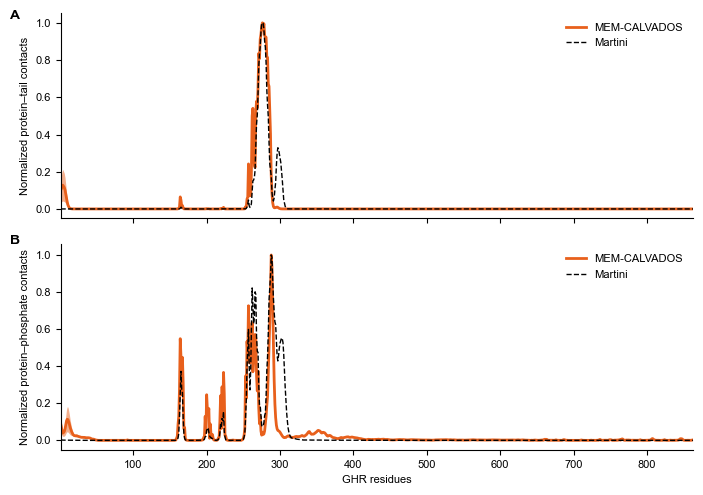

In [3]:
fig, (ax1,ax2) = plt.subplots(2, 1, figsize=(7, 5), sharex=True, sharey=False)
plt.rc('font', **{'family':'sans-serif','sans-serif':['Arial'], 'size': 8})

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_tail_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax1.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax1.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_tail_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax1.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

#######

contacts = np.array([
    np.load(f'data/GHR/GHR_{i}_protein_pho_cprofile.npy')
    for i in range(5)])
mean_contacts = contacts.mean(axis=0)
std_contacts = contacts.std(axis=0) 
std_contacts /= mean_contacts.max()
mean_contacts /= mean_contacts.max()
residues = np.arange(1, mean_contacts.size + 1)
ax2.plot(residues,mean_contacts,color=rnb_colors['orange2'],linewidth=2,label='MEM-CALVADOS')
ax2.fill_between(residues,mean_contacts - std_contacts,mean_contacts + std_contacts,
                 color=rnb_colors['orange2'],alpha=0.5,linewidth=0)

contacts = np.load(f'data/GHR/Martini_protein_pho_cprofile.npy')
contacts /= contacts.max()
residues = np.arange(1, contacts.size + 1)
ax2.plot(residues,contacts,color='k',linewidth=1,ls='--',label='Martini')

ax2.set_xlabel('GHR residues')
ax1.set_ylabel('Normalized protein–tail contacts')
ax2.set_ylabel('Normalized protein–phosphate contacts')
ax1.legend(frameon=False,handlelength=1.8)
ax2.legend(frameon=False,handlelength=1.8)
ax1.set_xlim(1,mean_contacts.size)
ax2.set_xlim(1,mean_contacts.size)
ax1.annotate('A',(-.08,.97),xycoords='axes fraction',fontsize=10,weight='bold')
ax2.annotate('B',(-.08,1),xycoords='axes fraction',fontsize=10,weight='bold')

ax1.spines['top'].set_visible(False)
ax1.spines['right'].set_visible(False)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('figS18.pdf')
plt.show()

'created' timestamp seems very low; regarding as unix timestamp
'modified' timestamp seems very low; regarding as unix timestamp


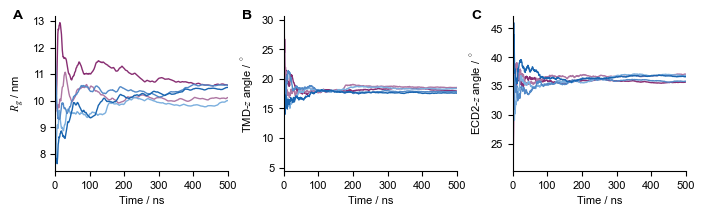

In [5]:
plt.rc('font', **{'family': 'sans-serif', 'sans-serif': ['Arial'], 'size': 8})

replica_colors = [rnb_colors[c] for c in ['purple3', 'purple2', 'blue3', 'blue2', 'blue1']]

fig, axes = plt.subplots(1, 3, figsize=(7, 2.2), sharex=True)
configs = [('rgs', 'FL', r'$R_g$ / nm'), ('angles', 'TMD', r'TMD-$z$ angle / ${^\circ}$'), ('angles', 'D2', r'ECD2-$z$ angle / ${^\circ}$')]

for ax, (kind, key, ylabel), label in zip(axes, configs, 'ABC'):
    for i, color in enumerate(replica_colors):
        data = np.load(f'data/GHR/GHR_{i}_domain_{kind}.npy', allow_pickle=True).item()
        y = data[key] if kind == 'rgs' else data[key][:, 0]
        time = 0.5 * np.arange(1, y.size + 1)
        ax.plot(time, np.cumsum(y) / np.arange(1, y.size + 1), color=color, lw=1)

    ax.set_xlabel('Time / ns')
    ax.set_ylabel(ylabel)
    ax.annotate(label, (-0.24, .98), xycoords='axes fraction', fontsize=10, fontweight='bold')
    
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

plt.xlim(0,500)
plt.tight_layout()
plt.savefig('figS19.pdf')
plt.show()